# 01 Data Preparation and Segmentation

## Project Objective

This notebook prepares customer survey participation data for analysis.

The objectives are:

1. Load survey participation data
2. Review customer response history
3. Create response-history segments
4. Calculate segment-level response rates
5. Generate summary tables for exploratory analysis

---

### Customer Segments

**Prior Responders**
- Surveyed in the previous two years
- Responded at least once

**Silent Customers**
- Surveyed in the previous two years
- Never responded

**New Customers**
- Not surveyed in the previous two years

---

### Expected Output

The notebook will produce:

- Segment counts
- Response rates by segment
- Summary tables for visualization

In [2]:
import pandas as pd
import numpy as np
import os

In [40]:
## Create folder structure- one time code
## Manually created "notebooks" to host this notebook

## un-comment out following codes if needed

##os.makedirs("data/raw", exist_ok=True)
##os.makedirs("data/processed", exist_ok=True)
##os.makedirs("outputs", exist_ok=True)

In [13]:
## Read in raw data
survey = pd.read_csv(
    "data/raw/survey_response_summary.csv"
)

survey

,year,segment,n,response_rate
0,2025,Prior Responders,103,0.69
1,2025,Silent Customers,60,0.28
2,2025,New Customers,121,0.39
3,2026,Prior Responders,100,0.71
4,2026,Silent Customers,70,0.20
5,2026,New Customers,76,0.38


## Review Dataset Structure

In [14]:
survey.shape

(6, 4)

In [15]:
survey.info()

<class 'pandas.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   year           6 non-null      int64  
 1   segment        6 non-null      str    
 2   n              6 non-null      int64  
 3   response_rate  6 non-null      float64
dtypes: float64(1), int64(2), str(1)
memory usage: 324.0 bytes


## Response Rates by Segment

In [16]:
survey

,year,segment,n,response_rate
0,2025,Prior Responders,103,0.69
1,2025,Silent Customers,60,0.28
2,2025,New Customers,121,0.39
3,2026,Prior Responders,100,0.71
4,2026,Silent Customers,70,0.20
5,2026,New Customers,76,0.38


## FY26 Response Rate by Customer Segment

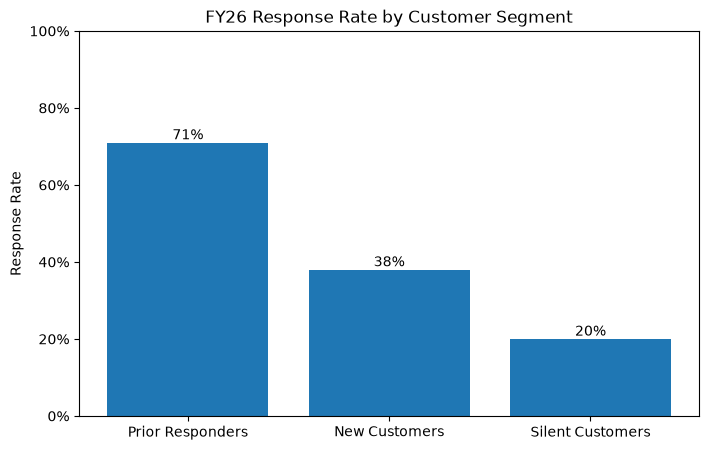

In [20]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

fy26 = survey[survey["year"] == 2026].copy()

## sort data to show segments by decending response rate
fy26 = fy26.sort_values(
    by="response_rate",
    ascending=False
)

plt.figure(figsize=(8,5))

bars = plt.bar(
    fy26["segment"],
    fy26["response_rate"]
)

plt.title("FY26 Response Rate by Customer Segment")
plt.ylabel("Response Rate")
plt.ylim(0, 1) ## Specity Y-axle range

plt.gca().yaxis.set_major_formatter(
    mtick.PercentFormatter(xmax=1)
)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.0%}", ## Show % format
        ha="center",
        va="bottom"
    )

plt.show()

## Key Finding

Prior response history was strongly associated with future survey participation.

Customers who responded to surveys in the previous two years had a 71% response rate in FY26, compared with 38% among new customers and only 20% among silent customers.

These findings suggest that prior response behavior is a strong predictor of future participation and may be useful for identifying groups that require targeted outreach strategies.

## Compare FY25 and FY26 Response Rates

In [21]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

pivot_df = survey.pivot(
    index="segment",
    columns="year",
    values="response_rate"
)

pivot_df

year,2025,2026
segment,,
New Customers,0.39,0.38
Prior Responders,0.69,0.71
Silent Customers,0.28,0.20


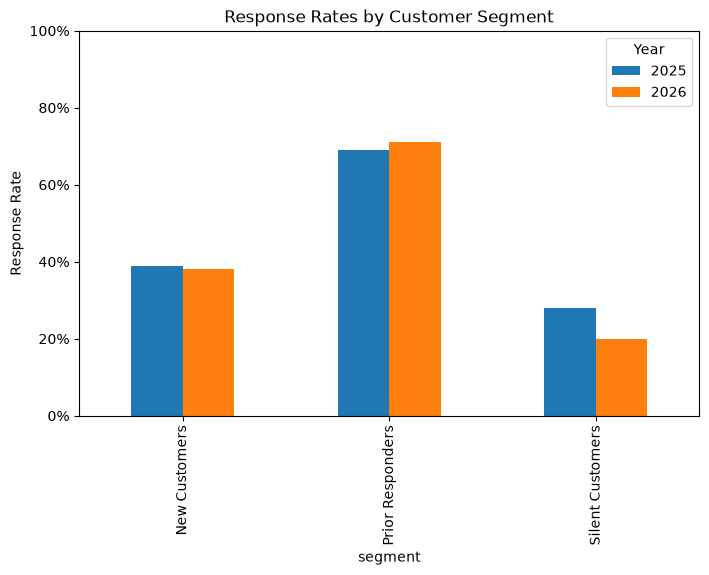

In [25]:
ax = pivot_df.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Response Rates by Customer Segment")
plt.ylabel("Response Rate")
plt.ylim(0, 1) ## Specity Y-axle range

ax.yaxis.set_major_formatter(
    mtick.PercentFormatter(xmax=1)
)

plt.legend(title="Year")

plt.show()

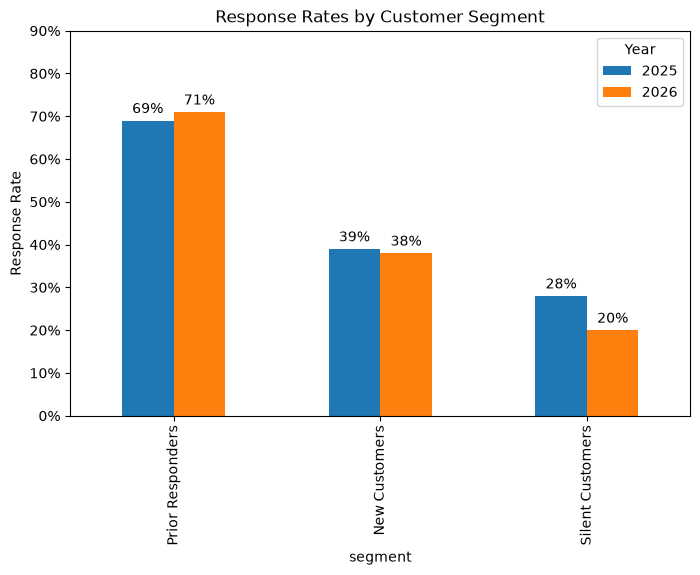

In [27]:


import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

## Set segment order to show RR in decending order
segment_order = [
    "Prior Responders",
    "New Customers",
    "Silent Customers"
]
pivot_df = pivot_df.loc[segment_order]

ax = pivot_df.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Response Rates by Customer Segment")
plt.ylabel("Response Rate")

ax.yaxis.set_major_formatter(
    mtick.PercentFormatter(xmax=1)
)

plt.ylim(0, 0.9)

# Add percentage labels above each bar
for container in ax.containers:
    ax.bar_label(
        container,
        fmt=lambda x: f"{x:.0%}",
        padding=3
    )

plt.legend(title="Year")

plt.show()

## Statistical Testing

To evaluate whether survey response rates differed across customer segments, a chi-square test of independence was conducted.

Null hypothesis:
Response behavior is independent of customer segment.

Alternative hypothesis:
Response behavior differs across customer segments.

In [28]:
## Add n_responded and n_not_responsded variables for Chi-square testing (with aggregate data)

survey["n_responded"] = (
    survey["n"] * survey["response_rate"]
).round().astype(int)

survey["n_not_responded"] = (
    survey["n"] - survey["n_responded"]
)

survey

,year,segment,n,response_rate,n_responded,n_not_responded
0,2025,Prior Responders,103,0.69,71,32
1,2025,Silent Customers,60,0.28,17,43
2,2025,New Customers,121,0.39,47,74
3,2026,Prior Responders,100,0.71,71,29
4,2026,Silent Customers,70,0.20,14,56
5,2026,New Customers,76,0.38,29,47


In [29]:
from scipy.stats import chi2_contingency

In [35]:
fy26 = survey[survey["year"] == 2026]

contingency26 = fy26[
    ["n_responded","n_not_responded"]
]

contingency

,n_responded,n_not_responded
0,71,32
1,17,43
2,47,74


In [36]:
chi2, p, dof, expected = chi2_contingency(
    contingency26
)

print(f"Chi-square statistic = {chi2:.2f}")
print(f"Degrees of freedom = {dof}")
print(f"P-value = {p:.6f}")

if p < 0.05:
    print(
        "Response rates differ significantly across customer segments."
    )
else:
    print(
        "No statistically significant differences were detected."
    )

Chi-square statistic = 46.03
Degrees of freedom = 2
P-value = 0.000000
Response rates differ significantly across customer segments.


## Statistical Findings

A chi-square test of independence was conducted to evaluate whether response behavior differed across customer segments.

FY26 results indicated a statistically significant association between customer segment and survey participation:

χ²(2) = 46.03, p < .001.

These findings support the conclusion that prior response history is strongly associated with future survey participation behavior.


## Run statistical testing (Chi-square testing) for 2025 data to verify pattern consistency
Next, we run the same Chi-square testing with the 2025 data to see if there's also significant difference across the segments (to see if there is a pattern in more than one year)

In [37]:
fy25 = survey[survey["year"] == 2025]

contingency25 = fy25[
    ["n_responded","n_not_responded"]
]

contingency25

,n_responded,n_not_responded
0,71,32
1,17,43
2,47,74


In [38]:
chi2, p, dof, expected = chi2_contingency(
    contingency25
)

print(f"Chi-square statistic = {chi2:.2f}")
print(f"Degrees of freedom = {dof}")
print(f"P-value = {p:.6f}")

if p < 0.05:
    print(
        "Response rates differ significantly across customer segments."
    )
else:
    print(
        "No statistically significant differences were detected."
    )

Chi-square statistic = 31.44
Degrees of freedom = 2
P-value = 0.000000
Response rates differ significantly across customer segments.


## Statistical Findings

A chi-square test of independence was conducted to evaluate whether response behavior differed across customer segments.

FY25 results indicated a statistically significant association between customer segment and survey participation:

χ²(2) = 31.44, p < .001.

These findings support the conclusion that prior response history is strongly associated with future survey participation behavior.
